<div align='center'>
<h1 style='font-size:40px;'>Using the <code>Star</code> Object</h1>
<h2 style='font-weight:400;'>Spectral data, normalization, and stellar properties</h2>
<p><em>Quick guide to stellar spectra handling in pyGrater</em></p>
</div>

---
**This tutorial covers:**
- Initializing a Star
- Accessing physical properties
- Plotting the normalized spectrum
- Resampling or restricting wavelength coverage
- Estimating luminosity
- Re-normalizing with custom wavelength ranges

## 1. Imports

In [ ]:
from pyGrater import Star
import matplotlib.pyplot as plt
import numpy as np


INFO - Logging to file: /Users/prioletp/PhD/public_codes/pyGrater/logs/pyGrater_20260623_172657.log (logging_config.py:line 152)


Distance [pc]: 19.44
Teff [K]: 8200.0
Radius [Rsun]: 1.759
log g: 4.2
Band normalized: V
Apparent magnitude: 3.86
Number of wavelength: 1459
Estimated luminosity [Lsun]: 9.163847080677623 m2


## 2. Instantiate a Star
To initialize a Star use the `Star` class and specify the name of the star with the keyword `star_name`. You can also specify the `bin_ratio` keyword to bin the stellar spectrum by a factor `bin_ratio`. Use the `talk` keyword for a talkative code.

The constructor loads basic properties (distance, temperature, radius, etc.) and fetches the closest synthetic spectrum (in logg and temperature) from the NextGen catalogue.

Normalization is done using the star's apparent magnitude and filter band listed in the data file.

In [2]:
star = Star(star_name='bPic', talk=False)  # Example star

print('Distance [pc]:', star.distance)
print('Teff [K]:', star.temp)
print('Radius [Rsun]:', star.radius)
print('log g:', star.logg)
print('Band normalized:', star.normband)
print('Apparent magnitude:', star.apmag)
print('Number of wavelength:', star.waves.size)

## 3. Inspect and plot the spectrum
The flux is stored in `star.flux` in Jy (normalized).

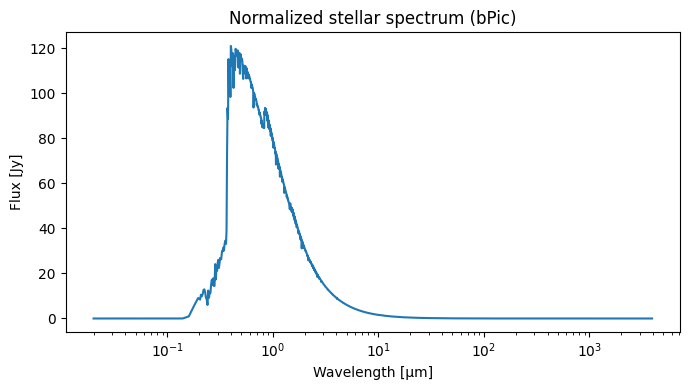

In [3]:
plt.figure(figsize=(7,4))
plt.semilogx(star.waves, star.flux, c='tab:blue')
plt.xlabel('Wavelength [µm]')
plt.ylabel('Flux [Jy]')
plt.title('Normalized stellar spectrum (bPic)')
plt.tight_layout()

## 6. Luminosity estimate
The `Star` object computes an approximate luminosity (in Lsun) after integrating the spectrum.

In [4]:
print('Estimated luminosity [Lsun]:', star.lum)

## 8. Summary
- `Star(name)` loads stellar properties and a synthetic spectrum
- Use `get_spectra()` to resample
- Toggle `norm` for observationally based normalization
- Access: `star.waves`, `star.flux`, `star.lum`, `star.temp`, `star.radius`, etc.

## 9. Creating a Star without the catalog

You do not need an entry in `stars_main_properties.txt` to create a `Star` object.
Pass the required properties directly as keyword arguments:

| kwarg  | unit | description |
|--------|------|-------------|
| `dist` | pc   | distance |
| `temp` | K    | effective temperature |
| `rad`  | R☉   | stellar radius |
| `logg` | cgs  | surface gravity |
| `band` | —    | photometric band for flux normalisation |
| `apmag`| mag  | apparent magnitude in that band |
| `spt`  | —    | spectral type *(optional)* |


In [ ]:
from pyGrater import Star

# Define a custom star entirely from kwargs — no catalog entry required.
# spectral type (spt) is optional.
custom_star = Star(
    dist  = 19.3,    # pc
    temp  = 8052,    # K
    rad   = 1.8,     # R_sun
    logg  = 4.1,     # cgs
    band  = "V",
    apmag = 3.86,    # apparent magnitude in V band
    spt   = "A6V",   # optional
)

print(f"Temperature : {custom_star.temp:.0f} K")
print(f"Distance    : {custom_star.distance:.1f} pc")
print(f"Luminosity  : {custom_star.lum:.2f} L_sun")
